____
# Nadir distance dependency


In [34]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import put_fig_letter, update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=12
distance_to_coast_max = 20e3
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Compute and project (x = cross, y = alg)

In [47]:
DT=12

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'diff_only',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [
    base_dic,
    update_dict(base_dic, dict(alti_diff_method = 'diff_only', ggd_var = 'etac'))
]

l = ['duacs','etac']
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [
    base_dic,
    update_dict(base_dic, dict(alti_diff_method = 'diff_only', ggd_var = 'etac'))
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<DT).dropna('row_number')
DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

214210
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0
221705
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etac__era5_rio0
Identified SWOT and drifter outliers have been removed
214210
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio15
221705
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etac__era5_rio15
Identified SWOT and drifter outliers have been removed


In [48]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy

In [49]:
DSr =  crossalg_proj(DS)  
D = dict()

dfr = DSr.sel(id_comb= 'duacs').to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'alti',f'alticoloc_{alti_product_key}_general_'+colocs_sources+'.csv')).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])
dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert']], dfr], axis=1).dropna()
D['Filtered L3-2km'] = dfrr

dfr = DSr.sel(id_comb = 'etac').to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'alti',f'alticoloc_{alti_product_key}_general_'+colocs_sources+'.csv')).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])
dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert']], dfr], axis=1).dropna()
D['Calibrated L3-2km'] = dfrr

_________
# Dependency on the cross_track distance

In [50]:
DSC = dict()
compute_error = 'centrallimit'
for k in D:
    dfrr = D[k]
    dfct = dfrr[dfrr.swh_model<2]
    ct_dist_bins = np.arange(0, 70000, 3000)
    dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
    dsc = compute_mean_square_groupby(dfct, groupby = 'abs_cross_track_distance_cut', dirname = ('x', 'y'), compute_error=compute_error, vars_errors = ['Ex_ggd']  )
    dsc['meanbin_swh_model'] = dfct.groupby('abs_cross_track_distance_cut', observed=False).swh_model.mean().dropna().to_xarray()
    dsc = dsc.where(dsc.nb_coloc>100)
    dsc['abs_cross_track_distance_cut'] = dsc['abs_cross_track_distance_cut']/1000
    DSC[k]=dsc.dropna('abs_cross_track_distance_cut')

/dev/shm/pbs.3157641.datarmor0/ipykernel_20791/124006913.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
/dev/shm/pbs.3157641.datarmor0/ipykernel_20791/124006913.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)


In [51]:
dsc.nb_coloc

<xarray.DataArray 'nb_coloc' (abs_cross_track_distance_cut: 23)> Size: 184B
array([   nan,    nan,    nan,    nan,    nan,  2881., 14261., 15246.,
       14964., 15448., 16755., 16464., 16835., 16338., 16827., 15972.,
       16027.,  3954.,    nan,    nan,    nan,    nan,    nan])
Coordinates:
  * abs_cross_track_distance_cut  (abs_cross_track_distance_cut) float64 184B ...

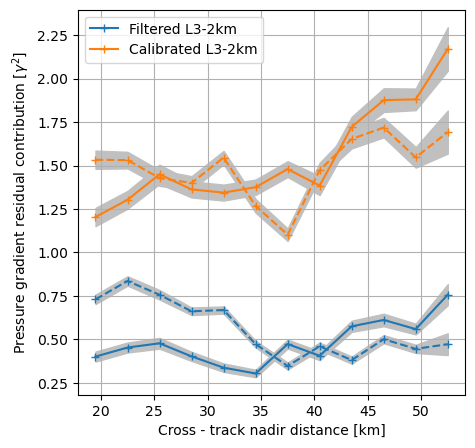

In [62]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(5,5), frameon=False)

c = ['tab:blue', 'tab:orange']
i=0
for k in DSC : 
    dsc = DSC[k].where(DSC[k].nb_coloc>3000, drop=True)
    #dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
    #dsc['ser__E_ggd'] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
    #dsc.Ex_ggd.plot(ax=ax, marker='+')
    #dsc.Ey_ggd.plot(ax=ax, marker='+')
    #dsc.E_ggd.plot(ax=ax, marker='+', label = k)
    dsc.Ex_ggd.plot(ax=ax, marker='+', ls='--', c=c[i])# cross track
    dsc.Ey_ggd.plot(ax=ax, marker='+',c=c[i], label = k)# along-track
    plot_error(dsc, 'abs_cross_track_distance_cut', 'Ex_ggd', ax=ax, suf='ser__')
    plot_error(dsc, 'abs_cross_track_distance_cut', 'Ey_ggd', ax=ax, suf='ser__')
    i+=1
    #sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
    #plt.colorbar(sc, label ='Mean swh on the bin [m]')
    
    #c = dsc.abs_cross_track_distance_cut
    #coef = np.polyfit(c, dsc.E_ggd,2,w =dsc.nb_coloc)
    #ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2])
    #print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track nadir distance [km]')
ax.legend()
#ax.set_ylim(0, 8.3)
#ax.set_xlim(8,62)

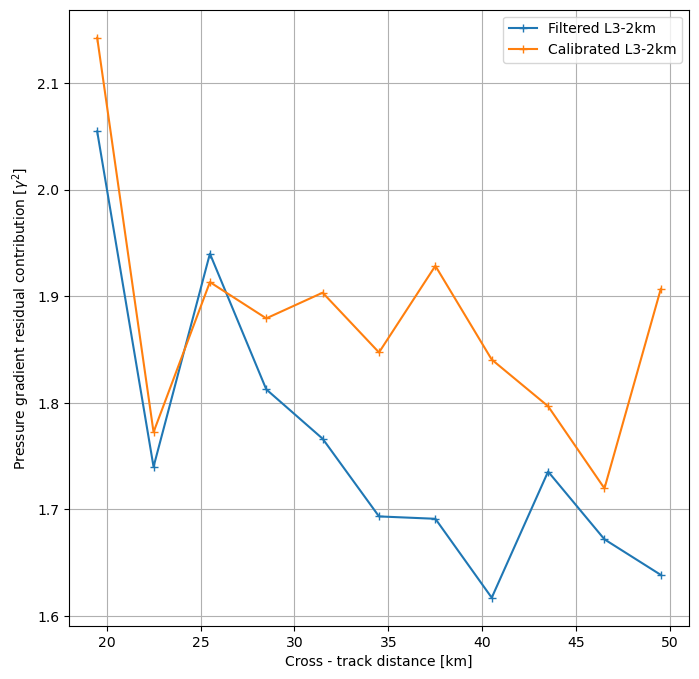

In [56]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
label = ['Calibrated L3-2km', 'Filtered L3-2km']
for k in DSC : 
    dsc = DSC[k].where(DSC[k].nb_coloc>10000, drop=True)
    dsc['B_ggd'] = dsc.Bx_ggd + dsc.By_ggd
    #dsc['ser__E_ggd'] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
    #dsc.Ex_ggd.plot(ax=ax, marker='+')
    #dsc.Ey_ggd.plot(ax=ax, marker='+')
    dsc.B_ggd.plot(ax=ax, marker='+', label = k)
    #plot_error(dsc, 'abs_cross_track_distance_cut', 'E_ggd', ax=ax, suf='ser__')
    #sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
    #plt.colorbar(sc, label ='Mean swh on the bin [m]')
    
    #c = dsc.abs_cross_track_distance_cut
    #coef = np.polyfit(c, dsc.E_ggd,2,w =dsc.nb_coloc)
    #ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2])
    #print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')
ax.legend()
#ax.set_ylim(0, 8.3)
#ax.set_xlim(8,62)

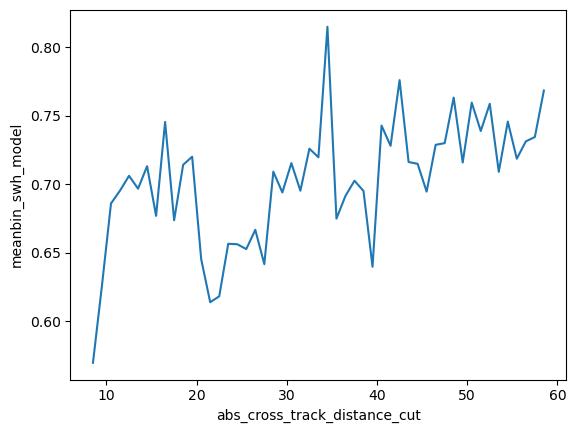

In [10]:
dsc.meanbin_swh_model.plot()

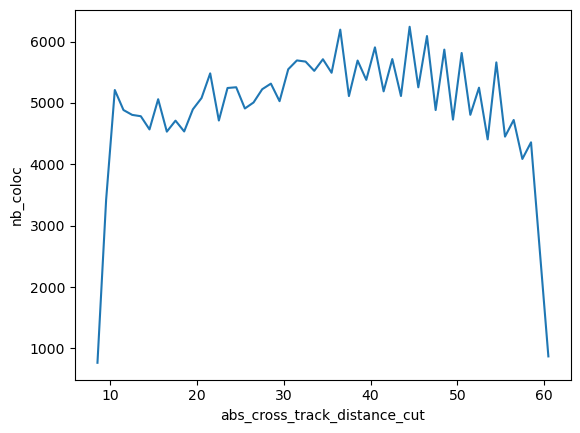

In [11]:
dsc.nb_coloc.plot()

Text(0.5, 0, 'Cross - track distance [km]')

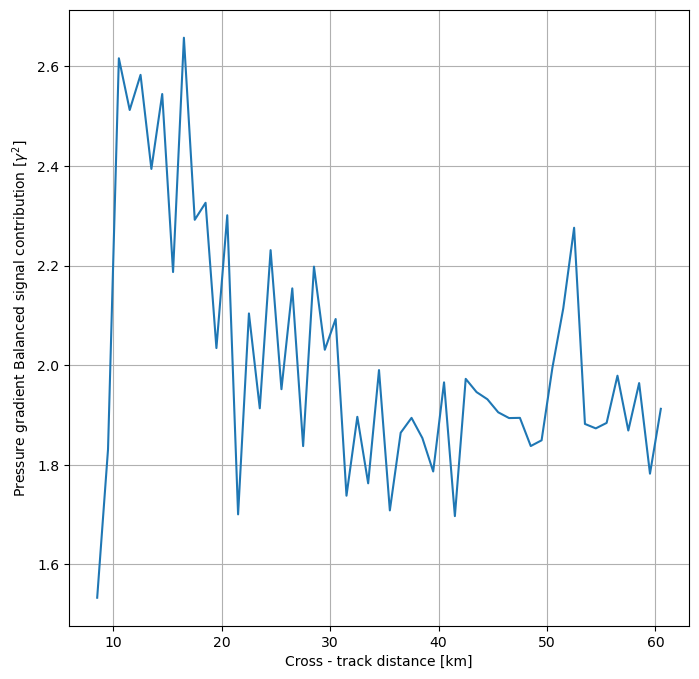

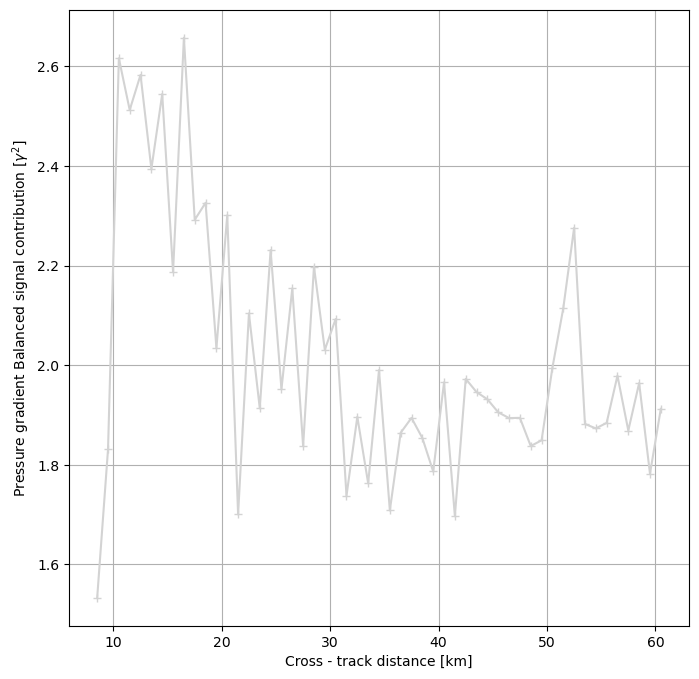

In [12]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsc['B_ggd'] = dsc.Bx_ggd + dsc.By_ggd

dsc.B_ggd.plot(ax=ax, marker='+', c='lightgrey')




ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

In [13]:
dss = dfrr.to_xarray()
plot_join_pdfs(dss, 'swh_model', 'abs_cross_track_distance', binx=100, biny=100)

NameError: name 'plot_join_pdfs' is not defined

# Binned on SWH too

In [19]:
compute_error = 'centrallimit'
DSB = dict()

for k in D:
    dfb = D[k].copy()
    # Cross_track distance
    ct_dist_bins = np.arange(0, 70000, 7000)
    dfb['abs_cross_track_distance_cut'] = pd.cut(dfb['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
    # SWH 
    swh_dist_bins = np.array([0, 1, 2])
    dfb['swh_model_cut'] = pd.cut(dfb['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
    
    # Binned diag
    dsc = compute_mean_square_groupby(dfb, groupby = ['abs_cross_track_distance_cut', 'swh_model_cut'], dirname = ('x', 'y'), compute_error=compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd']  )
    dsc = dsc.where(dsc.nb_coloc>100)
    dsc['abs_cross_track_distance_cut'] = dsc['abs_cross_track_distance_cut']/1000
    DSB[k]=dsc.dropna('abs_cross_track_distance_cut')
    

Text(0.5, 1.0, 'Surface + 15m and $\\Delta T$ < 12h')

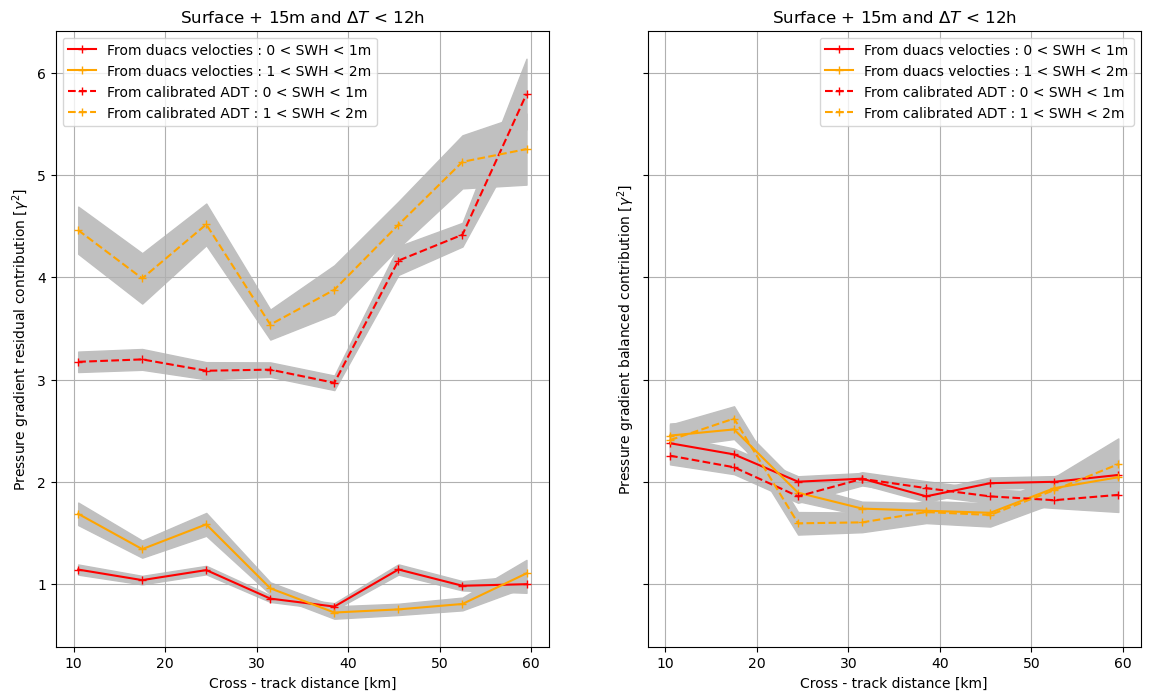

In [31]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,2, figsize=(14,8), frameon=False, sharey=True)
ax=axs[0]
lss = {'duacs':'-', 'etac':'--'}
labels = {'duacs':'From duacs velocties', 'etac':'From calibrated ADT'}
for k in DSB:
    dsc = DSB[k]
    dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
    dsc['ser__E_ggd'] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
    #dsc.Ex_ggd.plot(ax=ax, marker='+')
    #dsc.Ey_ggd.plot(ax=ax, marker='+')
    color = ['r', 'orange', 'g']
    for i in range(len(swh_dist_bins)-1):
        dsc.isel(swh_model_cut=i).E_ggd.plot(ax=ax, marker='+', c=color[i],label = labels[k] + f' : {swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m', ls=lss[k])
        plot_error(dsc.isel(swh_model_cut=i), 'abs_cross_track_distance_cut', 'E_ggd', ax=ax, suf='ser__')
    #sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
    #plt.colorbar(sc, label ='Mean swh on the bin [m]')
        #c = dsc.isel(swh_model_cut=i).abs_cross_track_distance_cut
        #coef = np.polyfit(c, dsc.isel(swh_model_cut=i).E_ggd,2,w =dsc.isel(swh_model_cut=i).nb_coloc)
        #ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2], color = color[i], ls=':')
        #print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

#ax.set_ylim(0, 3)
#ax.set_xlim(8,62)
ax.legend()
ax.set_title(rf'Surface + 15m and $\Delta T$ < {dt}h')

ax=axs[1]
for k in DSB:
    dsc = DSB[k]
    dsc['B_ggd'] = dsc.Bx_ggd + dsc.By_ggd
    dsc['ser__B_ggd'] = dsc.ser__Bx_ggd + dsc.ser__By_ggd
    #dsc.Ex_ggd.plot(ax=ax, marker='+')
    #dsc.Ey_ggd.plot(ax=ax, marker='+')
    color = ['r', 'orange', 'g']
    for i in range(len(swh_dist_bins)-1):
        dsc.isel(swh_model_cut=i).B_ggd.plot(ax=ax, marker='+', c=color[i], label = labels[k] + f' : {swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m', ls=lss[k])
        plot_error(dsc.isel(swh_model_cut=i), 'abs_cross_track_distance_cut', 'B_ggd', ax=ax, suf='ser__')
    #sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='B_ggd', c=dsc.meanbin_swh_model,zorder=10)
    #plt.colorbar(sc, label ='Mean swh on the bin [m]')
        #c = dsc.isel(swh_model_cut=i).abs_cross_track_distance_cut
        #coef = np.polyfit(c, dsc.isel(swh_model_cut=i).B_ggd,2,w =dsc.isel(swh_model_cut=i).nb_coloc)
        #ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2], color = color[i], ls=':',)
        #print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient balanced contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

#ax.set_ylim(0, 3)
#ax.set_xlim(8,62)
ax.legend()
ax.set_title(rf'Surface + 15m and $\Delta T$ < {dt}h')


Text(0.5, 1.0, 'Surface + 15m and $\\Delta T$ < 12h')

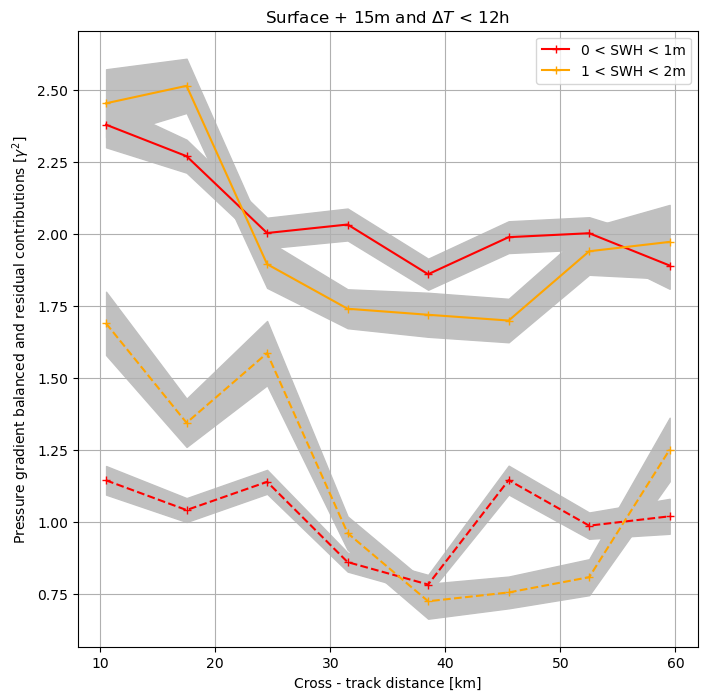

In [16]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(2, 1, figsize=(15,8), frameon=False, sharey= True)
dsc['B_ggd'] = dsc.Bx_ggd + dsc.By_ggd
dsc['ser__B_ggd'] = dsc.ser__Bx_ggd + dsc.ser__By_ggd
#dsc.Ex_ggd.plot(ax=ax, marker='+')
#dsc.Ey_ggd.plot(ax=ax, marker='+')
color = ['r', 'orange', 'g']
for i in range(len(swh_dist_bins)-1):
    dsc.isel(swh_model_cut=i).B_ggd.plot(ax=ax, marker='+', c=color[i], label = f'{swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m')
    plot_error(dsc.isel(swh_model_cut=i), 'abs_cross_track_distance_cut', 'B_ggd', ax=ax, suf='ser__')
#sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='B_ggd', c=dsc.meanbin_swh_model,zorder=10)
#plt.colorbar(sc, label ='Mean swh on the bin [m]')
    #c = dsc.isel(swh_model_cut=i).abs_cross_track_distance_cut
    #coef = np.polyfit(c, dsc.isel(swh_model_cut=i).B_ggd,2,w =dsc.isel(swh_model_cut=i).nb_coloc)
    #ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2], color = color[i], label = f'{swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m', ls=':')
    #print(coef)

dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
dsc['ser__E_ggd'] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
#dsc.Ex_ggd.plot(ax=ax, marker='+')
#dsc.Ey_ggd.plot(ax=ax, marker='+')
color = ['r', 'orange', 'g']
for i in range(len(swh_dist_bins)-1):
    dsc.isel(swh_model_cut=i).E_ggd.plot(ax=ax, marker='+', c=color[i],ls='--')#, label = f'{swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m')
    plot_error(dsc.isel(swh_model_cut=i), 'abs_cross_track_distance_cut', 'E_ggd', ax=ax, suf='ser__',)
#sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
#plt.colorbar(sc, label ='Mean swh on the bin [m]')
    #c = dsc.isel(swh_model_cut=i).abs_cross_track_distance_cut
    #coef = np.polyfit(c, dsc.isel(swh_model_cut=i).E_ggd,2,w =dsc.isel(swh_model_cut=i).nb_coloc)
    #ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2], color = color[i], label = f'{swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m')
    #print(coef)
ax.grid()
ax.set_ylabel(r'Pressure gradient balanced and residual contributions [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

#ax.set_ylim(0, 3)
#ax.set_xlim(8,62)
ax.legend()
ax.set_title(rf'Surface + 15m and $\Delta T$ < {dt}h')